In [1]:
# Iniciar sesión Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BigDataS2Lab") \
    .master("local[2]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")


Spark version: 4.0.3


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 50000

departamentos = ['Lima', 'Arequipa', 'La Libertad', 'Piura', 'Cusco',
                 'Junin', 'Puno', 'Ancash', 'Loreto', 'Cajamarca']
tipos = ['Choque', 'Atropello', 'Volcadura', 'Caida_ocupante', 'Incendio', 'Despiste']
causas = ['Exceso_velocidad', 'Impericia', 'Embriaguez', 'Exceso_carga',
          'Falla_mecanica', 'Mal_estado_via', 'Distraccion', 'No_respeta_señal']
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Setiembre','Octubre','Noviembre','Diciembre']

probs_dep = [0.35, 0.12, 0.10, 0.08, 0.07, 0.07, 0.05, 0.05, 0.06, 0.05]

data = {
    'ID_accidente': range(1, n+1),
    'departamento': np.random.choice(departamentos, n, p=probs_dep),
    'tipo_accidente': np.random.choice(tipos, n, p=[0.45, 0.20, 0.15, 0.10, 0.02, 0.08]),
    'causa_principal': np.random.choice(causas, n),
    'mes': np.random.choice(meses, n),
    'hora': np.random.randint(0, 24, n),
    'fallecidos': np.random.choice([0,1,2,3], n, p=[0.85, 0.10, 0.03, 0.02]),
    'heridos': np.random.randint(0, 8, n),
    'vehiculos_involucrados': np.random.randint(1, 5, n),
    'danio_material_soles': np.random.exponential(5000, n).astype(int)
}

df_pandas = pd.DataFrame(data)
df_pandas.to_csv('/tmp/accidentes_mtc_peru.csv', index=False)
print(f"Dataset creado: {len(df_pandas):,} registros")
df_pandas.head(3)


Dataset creado: 50,000 registros


,ID_accidente,departamento,tipo_accidente,causa_principal,mes,hora,fallecidos,heridos,vehiculos_involucrados,danio_material_soles
0,1,Arequipa,Caida_ocupante,Impericia,Agosto,18,0,2,1,2819
1,2,Cajamarca,Atropello,No_respeta_señal,Mayo,16,0,4,1,3384
2,3,Junin,Choque,Mal_estado_via,Agosto,15,0,2,2,3781


In [3]:
df = spark.read.csv('/tmp/accidentes_mtc_peru.csv',
                    header=True,
                    inferSchema=True)

df.printSchema()
df.show(5)
print(f"Total de registros: {df.count():,}")


root
 |-- ID_accidente: integer (nullable = true)
 |-- departamento: string (nullable = true)
 |-- tipo_accidente: string (nullable = true)
 |-- causa_principal: string (nullable = true)
 |-- mes: string (nullable = true)
 |-- hora: integer (nullable = true)
 |-- fallecidos: integer (nullable = true)
 |-- heridos: integer (nullable = true)
 |-- vehiculos_involucrados: integer (nullable = true)
 |-- danio_material_soles: integer (nullable = true)

+------------+------------+--------------+----------------+---------+----+----------+-------+----------------------+--------------------+
|ID_accidente|departamento|tipo_accidente| causa_principal|      mes|hora|fallecidos|heridos|vehiculos_involucrados|danio_material_soles|
+------------+------------+--------------+----------------+---------+----+----------+-------+----------------------+--------------------+
|           1|    Arequipa|Caida_ocupante|       Impericia|   Agosto|  18|         0|      2|                     1|                281

In [4]:
# Estadísticas descriptivas
df.describe().show()

# Filtrar accidentes fatales
accidentes_fatales = df.filter(df.fallecidos > 0)
print(f"Accidentes fatales: {accidentes_fatales.count():,}")
print(f"Porcentaje: {accidentes_fatales.count()/df.count()*100:.1f}%")

# Selección de columnas
df.select("departamento", "tipo_accidente", "fallecidos", "danio_material_soles").show(10)


+-------+-----------------+------------+--------------+----------------+---------+------------------+------------------+------------------+----------------------+--------------------+
|summary|     ID_accidente|departamento|tipo_accidente| causa_principal|      mes|              hora|        fallecidos|           heridos|vehiculos_involucrados|danio_material_soles|
+-------+-----------------+------------+--------------+----------------+---------+------------------+------------------+------------------+----------------------+--------------------+
|  count|            50000|       50000|         50000|           50000|    50000|             50000|             50000|             50000|                 50000|               50000|
|   mean|          25000.5|        NULL|          NULL|            NULL|     NULL|          11.43538|           0.21906|           3.49342|               2.49976|          4984.22894|
| stddev|14433.90106658626|        NULL|          NULL|            NULL|     NUL

In [5]:
from pyspark.sql import functions as F

analisis_departamento = df.groupBy("departamento") \
    .agg(
        F.count("*").alias("total_accidentes"),
        F.sum("fallecidos").alias("total_fallecidos"),
        F.sum("heridos").alias("total_heridos"),
        F.avg("danio_material_soles").alias("danio_promedio_soles"),
        F.sum("danio_material_soles").alias("danio_total_soles")
    ) \
    .orderBy("total_accidentes", ascending=False)

analisis_departamento.show()


+------------+----------------+----------------+-------------+--------------------+-----------------+
|departamento|total_accidentes|total_fallecidos|total_heridos|danio_promedio_soles|danio_total_soles|
+------------+----------------+----------------+-------------+--------------------+-----------------+
|        Lima|           17608|            3834|        61457|   4951.360801908224|         87183561|
|    Arequipa|            5953|            1302|        20753|   4957.260540903746|         29510572|
| La Libertad|            4984|            1077|        17367|   5032.992576243981|         25084435|
|       Piura|            4053|             909|        14291|   5086.247224278312|         20614560|
|       Cusco|            3525|             780|        12293|   5049.017021276596|         17797785|
|       Junin|            3474|             771|        12353|   4957.134427173287|         17221085|
|      Loreto|            3006|             643|        10312|   4999.356952761144

In [6]:
df_con_periodo = df.withColumn(
    "periodo_dia",
    F.when(F.col("hora").between(6, 11), "Mañana (6-11h)")
     .when(F.col("hora").between(12, 17), "Tarde (12-17h)")
     .when(F.col("hora").between(18, 23), "Noche (18-23h)")
     .otherwise("Madrugada (0-5h)")
)

analisis_temporal = df_con_periodo.groupBy("periodo_dia") \
    .agg(
        F.count("*").alias("total_accidentes"),
        F.sum("fallecidos").alias("fallecidos"),
        F.round(F.avg("danio_material_soles"), 2).alias("daño_promedio")
    )

analisis_temporal_con_tasa = analisis_temporal.withColumn(
    "tasa_mortalidad_pct",
    F.round(F.col("fallecidos") / F.col("total_accidentes") * 100, 2)
)

analisis_temporal_con_tasa.show()


+----------------+----------------+----------+-------------+-------------------+
|     periodo_dia|total_accidentes|fallecidos|daño_promedio|tasa_mortalidad_pct|
+----------------+----------------+----------+-------------+-------------------+
|Madrugada (0-5h)|           12622|      2885|      4953.06|              22.86|
|  Noche (18-23h)|           12303|      2659|      5006.36|              21.61|
|  Tarde (12-17h)|           12465|      2674|      5036.07|              21.45|
|  Mañana (6-11h)|           12610|      2735|      4942.59|              21.69|
+----------------+----------------+----------+-------------+-------------------+



In [7]:
df.createOrReplaceTempView("accidentes")

resultado_sql = spark.sql("""
    SELECT
        causa_principal,
        tipo_accidente,
        COUNT(*) as total_casos,
        SUM(fallecidos) as total_fallecidos,
        ROUND(SUM(fallecidos) * 100.0 / COUNT(*), 2) as tasa_mortalidad_pct
    FROM accidentes
    WHERE tipo_accidente IN ('Choque', 'Atropello', 'Volcadura')
    GROUP BY causa_principal, tipo_accidente
    HAVING COUNT(*) > 100
    ORDER BY total_fallecidos DESC
    LIMIT 15
""")

resultado_sql.show(15, truncate=False)


+----------------+--------------+-----------+----------------+-------------------+
|causa_principal |tipo_accidente|total_casos|total_fallecidos|tasa_mortalidad_pct|
+----------------+--------------+-----------+----------------+-------------------+
|Embriaguez      |Choque        |2789       |700             |25.10              |
|Impericia       |Choque        |2899       |646             |22.28              |
|No_respeta_señal|Choque        |2910       |633             |21.75              |
|Falla_mecanica  |Choque        |2802       |608             |21.70              |
|Exceso_carga    |Choque        |2810       |604             |21.49              |
|Mal_estado_via  |Choque        |2752       |593             |21.55              |
|Exceso_velocidad|Choque        |2769       |587             |21.20              |
|Distraccion     |Choque        |2665       |573             |21.50              |
|Distraccion     |Atropello     |1288       |305             |23.68              |
|Exc

In [8]:
# Bronze
print(f"BRONZE: Registros {df.count():,}")

# Silver
df_silver = df.filter(df.danio_material_soles > 0) \
    .filter(df.hora.between(0, 23)) \
    .withColumn("es_fatal", F.when(df.fallecidos > 0, True).otherwise(False)) \
    .withColumn("costo_total",
                F.col("danio_material_soles") + F.col("heridos")*2000 + F.col("fallecidos")*50000)

print(f"SILVER: Registros {df_silver.count():,}")

# Gold
df_gold = df_silver.groupBy("departamento", "mes") \
    .agg(
        F.count("*").alias("accidentes"),
        F.sum("fallecidos").alias("fallecidos"),
        F.sum("heridos").alias("heridos"),
        F.sum("costo_total").alias("costo_total_estimado"),
        F.sum(F.col("es_fatal").cast("int")).alias("accidentes_fatales")
    ) \
    .withColumn("tasa_fatalidad_pct",
                F.round(F.col("accidentes_fatales") / F.col("accidentes") * 100, 2))

df_gold.show(10)


BRONZE: Registros 50,000
SILVER: Registros 49,988
+------------+---------+----------+----------+-------+--------------------+------------------+------------------+
|departamento|      mes|accidentes|fallecidos|heridos|costo_total_estimado|accidentes_fatales|tasa_fatalidad_pct|
+------------+---------+----------+----------+-------+--------------------+------------------+------------------+
| La Libertad|  Octubre|       414|        83|   1445|             9213169|                57|             13.77|
|        Puno|Setiembre|       210|        40|    684|             4478641|                27|             12.86|
|       Junin|    Abril|       295|        58|   1024|             6429189|                43|             14.58|
|    Arequipa|Setiembre|       466|        93|   1650|            10255680|                65|             13.95|
|        Puno|    Abril|       197|        45|    660|             4489938|                32|             16.24|
|       Junin|Setiembre|       298|   

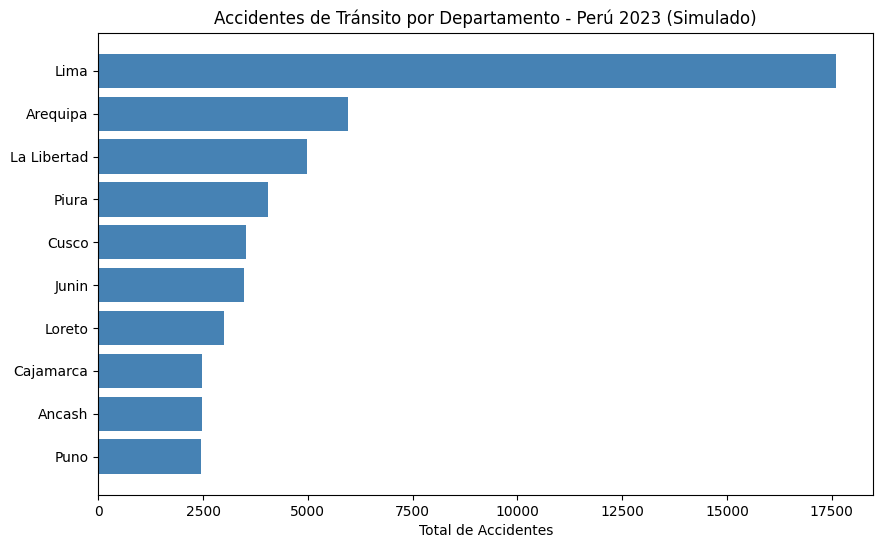

In [9]:
import matplotlib.pyplot as plt

df_viz = analisis_departamento.toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_viz['departamento'], df_viz['total_accidentes'], color='steelblue')
ax.set_xlabel('Total de Accidentes')
ax.set_title('Accidentes de Tránsito por Departamento - Perú 2023 (Simulado)')
ax.invert_yaxis()
plt.show()
